In [1]:
#Cargando el dataset desde Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Path to dataset files:", path)
#Copiar y pegar de forma manual el archivo al directorio de trabajo

c:\Users\duvan\taller3_IA\virtual\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\duvan\.cache\kagglehub\datasets\uciml\breast-cancer-wisconsin-data\versions\2


In [2]:
#Cargar datos y mostrar las primeras 10 filas 
import pandas as pd
datos = pd.read_csv("data.csv")

In [3]:
# Análisis de clustering jerárquico para el DataFrame `datos`
#Cargar las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import warnings

sns.set(style='whitegrid')


In [4]:
# 1) Inspección rápida
display(datos.head(5))
print('\nInformación básica:')
print(datos.info())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Información básica:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perim

In [6]:
# 2) Preparar variables para clustering
# - Seleccionamos columnas numéricas
numeric_cols = datos.select_dtypes(include=[np.number]).columns.tolist()
# - Excluir columnas de ID
id_candidates = [c for c in numeric_cols if c.lower().startswith(('id'))]
numeric_cols = [c for c in numeric_cols if c not in id_candidates]

# Si existen columnas categóricas útiles, codificarlas (solo si pocas categorías)
cat_cols = datos.select_dtypes(include=['object', 'category']).columns.tolist()
low_card_cat = [c for c in cat_cols if datos[c].nunique() <= 10]
if low_card_cat:
    print('\nCodificando variables categóricas de baja cardinalidad:', low_card_cat)
    datos_encoded = pd.get_dummies(datos[low_card_cat].astype(str), drop_first=True)
else:
    datos_encoded = pd.DataFrame()

# Construir matriz de características
if not numeric_cols and datos_encoded.shape[1] == 0:
    raise ValueError('No hay columnas numéricas ni categóricas aptas para clustering.')

X_df = pd.DataFrame()
if numeric_cols:
    X_df = datos[numeric_cols].copy()
if not datos_encoded.empty:
    X_df = pd.concat([X_df, datos_encoded], axis=1)

print('\nVariables usadas para clustering ({}):'.format(X_df.shape[1]))
print(X_df.columns.tolist())


Codificando variables categóricas de baja cardinalidad: ['diagnosis']

Variables usadas para clustering (32):
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32', 'diagnosis_M']


In [7]:
# 3) Imputación y escalado
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_df)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

c:\Users\duvan\taller3_IA\virtual\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [8]:
# 4) Cálculo del linkage (Ward si las variables son continuas)
method = 'ward' if X_scaled.shape[1] >= 1 else 'average'
Z = linkage(X_scaled, method='ward')

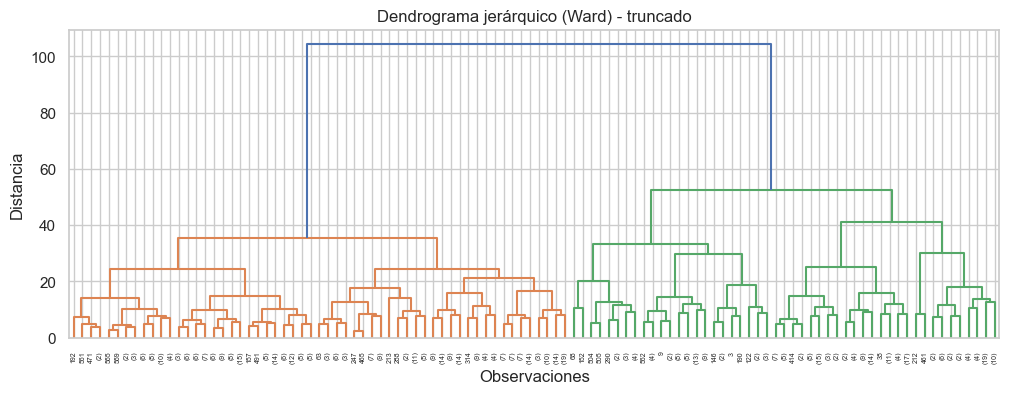

In [9]:
# 5) Dendrograma (truncado para mayor legibilidad)
plt.figure(figsize=(12, 4))
dendrogram(Z, truncate_mode='level', p=6)
plt.title('Dendrograma jerárquico (Ward) - truncado')
plt.xlabel('Observaciones')
plt.ylabel('Distancia')
plt.show()


Silhouette scores:
 k  silhouette
 2    0.319831
 3    0.306537
 4    0.231508
 5    0.105703
 6    0.114322


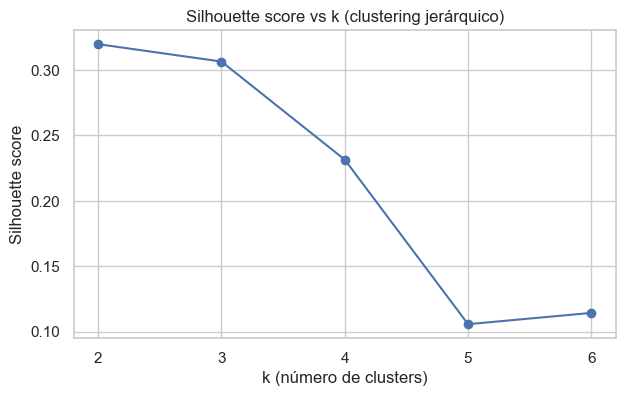


K óptimo según silhouette: 2 (score=0.320)


In [10]:
# 6) Búsqueda de k óptimo mediante Silhouette (k entre 2 y 6)
ks = list(range(2, 7))
sil_scores = []
for k in ks:
    labels = fcluster(Z, k, criterion='maxclust')
    # silhouette requiere al menos 2 clusters y menos clusters que muestras
    try:
        s = silhouette_score(X_scaled, labels)
    except Exception as e:
        warnings.warn(f"No se pudo calcular silhouette para k={k}: {e}")
        s = np.nan
    sil_scores.append(s)

res = pd.DataFrame({'k': ks, 'silhouette': sil_scores})
print('\nSilhouette scores:')
print(res.to_string(index=False))

plt.figure(figsize=(7,4))
plt.plot(ks, sil_scores, marker='o')
plt.xticks(ks)
plt.xlabel('k (número de clusters)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score vs k (clustering jerárquico)')
plt.grid(True)
plt.show()

# Elegir k con mejor silhouette (ignorando NaN)
valid = res.dropna()
if not valid.empty:
    best_k = int(valid.loc[valid['silhouette'].idxmax(), 'k'])
    print(f"\nK óptimo según silhouette: {best_k} (score={valid['silhouette'].max():.3f})")
else:
    best_k = ks[0]
    print(f"\nNo se obtuvieron silhouette válidos; se usará k={best_k} por defecto.")


Tamaños por cluster:
cluster_hier_k2
1    345
2    224
Name: count, dtype: int64

Según la información del dataset, el número de observaciones por categoría en 'diagnosis' es:
diagnosis
B    357
M    212
Name: count, dtype: int64

Leyenda: B = Benigno, M = Maligno

Resumen por cluster (medias de variables numéricas):
                 radius_mean  texture_mean  perimeter_mean  area_mean  \
cluster_hier_k2                                                         
1                     12.235        17.938          78.575    469.197   
2                     17.042        21.371         112.598    940.889   

                 smoothness_mean  compactness_mean  concavity_mean  \
cluster_hier_k2                                                      
1                          0.092             0.077           0.041   
2                          0.103             0.147           0.163   

                 concave points_mean  symmetry_mean  fractal_dimension_mean  \
cluster_hier_k2            

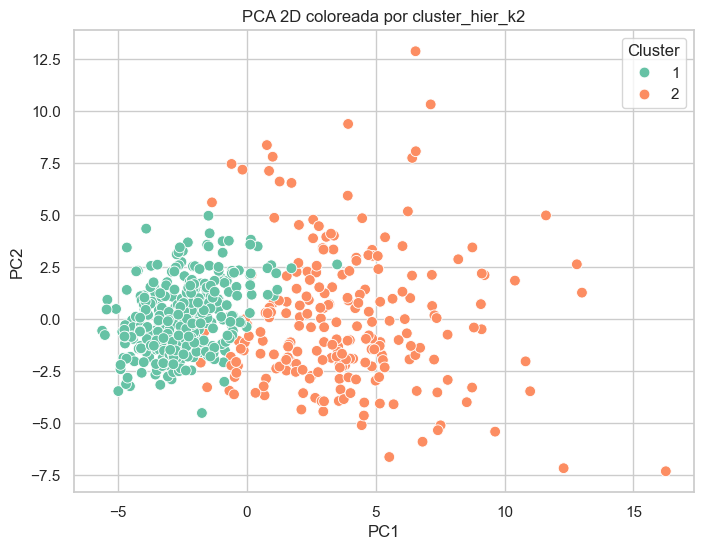


Se añadió la columna "cluster_hier_k2" al DataFrame `datos`.


In [11]:

# 7) Asignar clusters al DataFrame `datos` y mostrar resumen
labels_best = fcluster(Z, best_k, criterion='maxclust')
cluster_col = f'cluster_hier_k{best_k}'
datos[cluster_col] = labels_best

print('\nTamaños por cluster:')
print(datos[cluster_col].value_counts().sort_index())

# Imprimiendo el número de observaciones benignas y malignas en el dataset original
col = 'diagnosis'
if col in datos.columns:
    counts = datos[col].value_counts()
    print(f"\nSegún la información del dataset, el número de observaciones por categoría en '{col}' es:")
    print(counts)
    # Si las etiquetas son 'B' y 'M', mostrar una línea aclaratoria
    if all(x in counts.index for x in ['B','M']):
        print("\nLeyenda: B = Benigno, M = Maligno")
else:
    print(f"La columna '{col}' no existe en el DataFrame `datos`. Columnas disponibles:\n{list(datos.columns)}")


# Resumen por cluster (medias de variables numéricas)
print('\nResumen por cluster (medias de variables numéricas):')
print(datos.groupby(cluster_col)[numeric_cols].mean().round(3))

# 8) Visualización PCA 2D coloreada por cluster
pca = PCA(n_components=2)
pc = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=pc[:,0], y=pc[:,1], hue=labels_best, palette='Set2', s=60)
plt.title(f'PCA 2D coloreada por {cluster_col}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

print('\nSe añadió la columna "{}" al DataFrame `datos`.'.format(cluster_col))




In [12]:
# Medidas de desempeño del clustering jerárquico usando la variable diagnosis como referencia
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, normalized_mutual_info_score, homogeneity_score, completeness_score, v_measure_score

# Definir variable de referencia y de clusters
ref_col = 'diagnosis'
cluster_col = [c for c in datos.columns if c.startswith('cluster_hier_k')]
if not cluster_col:
    raise ValueError('No se encontró columna de clusters jerárquicos en el DataFrame.')
cluster_col = cluster_col[-1]  # Usar la última generada

# Convertir diagnosis a valores numéricos si es necesario
if datos[ref_col].dtype == 'object':
    ref_labels = datos[ref_col].astype('category').cat.codes.values
else:
    ref_labels = datos[ref_col].values
cluster_labels = datos[cluster_col].values

print(f"\nEvaluando desempeño del clustering respecto a la variable independiente '{ref_col}':")

# Medidas de desempeño
ari = adjusted_rand_score(ref_labels, cluster_labels)
ami = adjusted_mutual_info_score(ref_labels, cluster_labels)
nmi = normalized_mutual_info_score(ref_labels, cluster_labels)
hom = homogeneity_score(ref_labels, cluster_labels)
comp = completeness_score(ref_labels, cluster_labels)
vmeas = v_measure_score(ref_labels, cluster_labels)

print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Adjusted Mutual Info (AMI): {ami:.3f}")
print(f"Normalized Mutual Info (NMI): {nmi:.3f}")
print(f"Homogeneity: {hom:.3f}")
print(f"Completeness: {comp:.3f}")
print(f"V-measure: {vmeas:.3f}")

# Matriz de confusión entre diagnosis y cluster
import pandas as pd
conf_matrix = pd.crosstab(datos[ref_col], datos[cluster_col], rownames=[ref_col], colnames=[cluster_col])
print("\nMatriz de confusión entre diagnosis y cluster:")
print(conf_matrix)



Evaluando desempeño del clustering respecto a la variable independiente 'diagnosis':
Adjusted Rand Index (ARI): 0.890
Adjusted Mutual Info (AMI): 0.821
Normalized Mutual Info (NMI): 0.822
Homogeneity: 0.828
Completeness: 0.815
V-measure: 0.822

Matriz de confusión entre diagnosis y cluster:
cluster_hier_k2    1    2
diagnosis                
B                343   14
M                  2  210
